# Homework 5 - Exercise 1

Extracted from `HW5_completed.ipynb`. This notebook contains only Exercise 1 plus the shared helper cell needed to run it independently.

In [1]:
import os
import random

# Force TensorFlow onto CPU and suppress most informational logging so the
# notebook output stays readable when it is re-run.
os.environ.setdefault("CUDA_VISIBLE_DEVICES", "-1")
os.environ.setdefault("TF_CPP_MIN_LOG_LEVEL", "2")

import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

GLOBAL_SEED = 3
EX1_IMAGE_SIZE = 50
EX1_STRIPE_COUNT = 10


def configure_runtime(seed=GLOBAL_SEED):
    random.seed(seed)
    np.random.seed(seed)
    tf.keras.utils.set_random_seed(seed)
    tf.config.threading.set_inter_op_parallelism_threads(1)
    tf.config.threading.set_intra_op_parallelism_threads(1)


def generate_stripe_image(size, stripe_nr, vertical, rng):
    image = np.zeros((size, size, 1), dtype=np.uint8)
    for _ in range(stripe_nr):
        x, y = rng.integers(0, size, 2)
        end = int(rng.integers(y, size))
        if vertical:
            image[y:end, x, 0] = 255
        else:
            image[x, y:end, 0] = 255
    return image


def make_stripe_dataset(total_images, seed):
    rng = np.random.default_rng(seed)
    per_class = total_images // 2
    vertical = [generate_stripe_image(EX1_IMAGE_SIZE, EX1_STRIPE_COUNT, True, rng) for _ in range(per_class)]
    horizontal = [generate_stripe_image(EX1_IMAGE_SIZE, EX1_STRIPE_COUNT, False, rng) for _ in range(per_class)]
    x = np.stack(vertical + horizontal).astype("float32") / 255.0
    y = np.array([0] * per_class + [1] * per_class, dtype=np.int64)
    order = rng.permutation(total_images)
    return x[order], y[order]


def build_conv_model(kernel_size, conv_activation="linear", pooling="max"):
    tf.keras.backend.clear_session()
    if pooling == "max":
        pooling_layer = layers.MaxPooling2D(pool_size=(50, 50))
    elif pooling == "average":
        pooling_layer = layers.AveragePooling2D(pool_size=(50, 50))
    else:
        raise ValueError(pooling)

    model = keras.Sequential(
        [
            layers.Input(shape=(50, 50, 1)),
            layers.Conv2D(1, (kernel_size, kernel_size), activation=conv_activation, padding="same"),
            pooling_layer,
            layers.Flatten(),
            layers.Dense(2, activation="softmax"),
        ]
    )
    model.compile(loss="categorical_crossentropy", optimizer="adam", metrics=["accuracy"])
    return model


def train_exercise_1_model(x_train, y_train, x_val, y_val, kernel_size=5, conv_activation="linear", pooling="max", seed=GLOBAL_SEED):
    tf.keras.utils.set_random_seed(seed)
    model = build_conv_model(kernel_size=kernel_size, conv_activation=conv_activation, pooling=pooling)
    history = model.fit(
        x_train,
        y_train,
        validation_data=(x_val, y_val),
        batch_size=64,
        epochs=50,
        verbose=0,
        shuffle=True,
    )
    return model, history


configure_runtime()


## Exercise 1

We generate `1000` training images and `1000` validation images, each of size `50x50x1`, with exactly `500` vertical and `500` horizontal stripe images in each split. The labels use `0 = vertical` and `1 = horizontal`, followed by one-hot encoding.


In [2]:
# Build the balanced training and validation sets exactly as requested.
x_train, y_train_raw = make_stripe_dataset(1000, seed=GLOBAL_SEED)
x_val, y_val_raw = make_stripe_dataset(1000, seed=GLOBAL_SEED + 1)

# Convert integer class labels into one-hot vectors because the model is trained
# with categorical cross-entropy.
y_train = keras.utils.to_categorical(y_train_raw, num_classes=2)
y_val = keras.utils.to_categorical(y_val_raw, num_classes=2)

# Train the baseline architecture from the assignment statement.
baseline_model, baseline_history = train_exercise_1_model(x_train, y_train, x_val, y_val)

# Extract the learned 5x5 filter so we can inspect it visually afterward.
baseline_kernel = baseline_model.get_weights()[0][:, :, 0, 0]

# Print the dataset sizes and final training summary for direct reference.
print("X_train shape:", x_train.shape)
print("X_val shape:", x_val.shape)
print("Training label counts:", np.bincount(y_train_raw))
print("Validation label counts:", np.bincount(y_val_raw))
print("Parameter count:", baseline_model.count_params())
print("Final training accuracy:", baseline_history.history["accuracy"][-1])
print("Final validation accuracy:", baseline_history.history["val_accuracy"][-1])
print("Final validation loss:", baseline_history.history["val_loss"][-1])


X_train shape: (1000, 50, 50, 1)
X_val shape: (1000, 50, 50, 1)
Training label counts: [500 500]
Validation label counts: [500 500]
Parameter count: 30
Final training accuracy: 1.0
Final validation accuracy: 1.0
Final validation loss: 0.12714146077632904


**Exercise 1.3 answer.** With `same` padding, the network has

$$
(5\cdot 5\cdot 1\cdot 1 + 1) + (1\cdot 2 + 2) = 26 + 4 = 30
$$

trainable parameters.


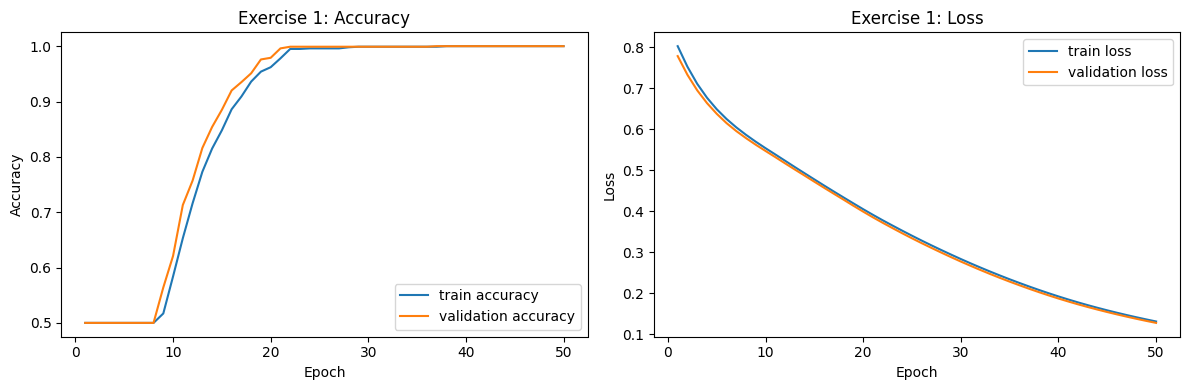

In [3]:
# Use the recorded history object from Keras to plot how both accuracy and loss
# evolve over the 50 training epochs.
epochs = np.arange(1, len(baseline_history.history["accuracy"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left panel: classification accuracy for training and validation sets.
axes[0].plot(epochs, baseline_history.history["accuracy"], label="train accuracy")
axes[0].plot(epochs, baseline_history.history["val_accuracy"], label="validation accuracy")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].set_title("Exercise 1: Accuracy")
axes[0].legend()

# Right panel: training and validation loss to check optimization behavior.
axes[1].plot(epochs, baseline_history.history["loss"], label="train loss")
axes[1].plot(epochs, baseline_history.history["val_loss"], label="validation loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Exercise 1: Loss")
axes[1].legend()

plt.tight_layout()
# plt.savefig("ex1_accuracy_loss.png", dpi=200, bbox_inches="tight")
plt.show()


**Exercise 1.4 answer.** The baseline model reached a final training accuracy of `1.0000` and a final validation accuracy of `1.0000`. The final validation loss was `0.1271`, and the validation accuracy first hit `100%` at epoch `37`.


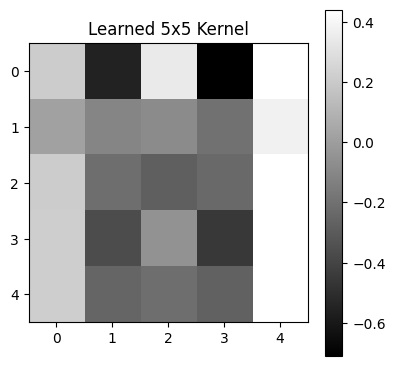

[[ 0.2089 -0.5544  0.3448 -0.7104  0.4404]
 [ 0.0144 -0.1082 -0.0844 -0.2005  0.3766]
 [ 0.2093 -0.2122 -0.2803 -0.2312  0.4406]
 [ 0.2164 -0.3685 -0.052  -0.456   0.4406]
 [ 0.2162 -0.2528 -0.2148 -0.2665  0.4402]]


In [4]:
# Display the single learned convolution kernel as a grayscale image so we can
# interpret which spatial pattern the network found useful.
plt.figure(figsize=(4.5, 4.5))
plt.imshow(baseline_kernel, cmap="gray")
plt.colorbar()
plt.title("Learned 5x5 Kernel")
# plt.savefig("ex1_kernel.png", dpi=200, bbox_inches="tight")
plt.show()

# Also print the numerical values for the write-up.
print(np.round(baseline_kernel, 4))


**Exercise 1.5 answer.** The kernel varies much more strongly by **column** than by row, so it is acting mainly as a detector of vertical structure. That is a reasonable outcome: vertical stripes create concentrated column-wise responses, and the global max-pooling layer can keep the strongest such response anywhere in the image. Horizontal stripes do not excite the filter in the same way.


In [5]:
# Compare the baseline model to the variants requested in the assignment:
# ReLU instead of linear activation, average pooling instead of max pooling,
# and different kernel sizes.
ex1_variants = [
    {"name": "relu_conv", "conv_activation": "relu", "pooling": "max", "kernel_size": 5, "seed": GLOBAL_SEED + 11},
    {"name": "average_pool", "conv_activation": "linear", "pooling": "average", "kernel_size": 5, "seed": GLOBAL_SEED + 12},
    {"name": "kernel_3", "conv_activation": "linear", "pooling": "max", "kernel_size": 3, "seed": GLOBAL_SEED + 13},
    {"name": "kernel_7", "conv_activation": "linear", "pooling": "max", "kernel_size": 7, "seed": GLOBAL_SEED + 14},
]

ex1_variant_results = {}
for variant in ex1_variants:
    # Re-train from scratch for each design choice so the comparison is fair.
    _, history = train_exercise_1_model(
        x_train,
        y_train,
        x_val,
        y_val,
        kernel_size=variant["kernel_size"],
        conv_activation=variant["conv_activation"],
        pooling=variant["pooling"],
        seed=variant["seed"],
    )
    ex1_variant_results[variant["name"]] = {
        "final_val_accuracy": history.history["val_accuracy"][-1],
        "final_val_loss": history.history["val_loss"][-1],
    }

ex1_variant_results


{'relu_conv': {'final_val_accuracy': 1.0,
  'final_val_loss': 0.20796847343444824},
 'average_pool': {'final_val_accuracy': 0.5889999866485596,
  'final_val_loss': 0.6920753717422485},
 'kernel_3': {'final_val_accuracy': 0.5, 'final_val_loss': 0.6922290921211243},
 'kernel_7': {'final_val_accuracy': 1.0,
  'final_val_loss': 0.07430224120616913}}

**Exercise 1.6 answer.**

- ReLU instead of linear still worked well: final validation accuracy was `1.000`, but the final validation loss increased to about `0.208`, so the model was less confident.
- Average pooling performed poorly: final validation accuracy was about `0.589`, which is close to chance. The averaging step suppresses the strongest local orientation response that max pooling preserves.
- A `3x3` kernel failed in this one-filter architecture: final validation accuracy was about `0.500`.
- A `7x7` kernel worked very well and gave the best final validation loss among the tested variants (`0.0743`), suggesting that the larger receptive field made orientation detection easier.
